In this notebook the datset is very small so the recommendation system will not work well if we  go through the same logic  and try to take big dataset it will work good


In [ ]:
import pandas as pd
import numpy as np

In [110]:
import os

print(os.path.exists("images"))

True


In [111]:
os.listdir("images")[:5]

['14088808_0.jpg',
 '17805751_0.jpg',
 '15517043_4.jpg',
 '17111227_1.jpg',
 '16115324_2.jpg']

In [112]:
df=pd.read_json('farfetch_fashion_dataset_images_crawlfeeds.json')




In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   url              141 non-null    object        
 1   title            141 non-null    object        
 2   brand            141 non-null    object        
 3   price            141 non-null    int64         
 4   currency         141 non-null    object        
 5   formatted_price  141 non-null    object        
 6   availability     141 non-null    object        
 7   item_id          141 non-null    int64         
 8   sku              141 non-null    int64         
 9   condition        141 non-null    object        
 10  images           141 non-null    object        
 11  description      141 non-null    object        
 12  breadcrumbs      141 non-null    object        
 13  gender           141 non-null    object        
 14  details          141 non-null    object   

In [114]:
df.head()
df['availability'].unique()
df['gender'].unique()
df.head()
df.shape

(141, 18)

In [7]:
df['breadcrumbs']=df['breadcrumbs'].str.split(',').str[2:]

In [8]:
df['availability']=df['availability'].replace({'In Stock':1,'Out Stock':0})

df['formatted_price']=df['formatted_price'].str.split('$').str[1]

/var/folders/mx/zj8ldfqx7hn8ykwf8cfgz9sw0000gn/T/ipykernel_2720/1293154164.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['availability']=df['availability'].replace({'In Stock':1,'Out Stock':0})


In [9]:
df['title']=df['title'].str.split(' ').str[-1]

In [10]:
df = df[df['title'].str.strip() != ""]

In [11]:
df.head()

,url,title,brand,price,currency,formatted_price,availability,item_id,sku,condition,images,description,breadcrumbs,gender,details,uniq_id,scraped_at,image_file
0,https://www.farfetch.com/shopping/women/emilio...,scarf,PUCCI,365,USD,365,1,15652262,15652262,NewCondition,https://cdn-images.farfetch-contents.com/15/65...,Little details can make all the difference in ...,[ Accessories],Women,"<div aria-labelledby=""tab-0"" class=""ltr-cmgatk...",cfde5600-4665-5107-8fee-adeb00b6bc25,2022-10-14 12:22:20,images/15652262_0.jpg | images/15652262_1.jpg ...
3,https://www.farfetch.com/shopping/women/jil-sa...,skirt,Jil Sander,1005,USD,"1,005",1,16354560,16354560,NewCondition,https://cdn-images.farfetch-contents.com/16/35...,"Change is good. So, switch up your loungewear ...",[ Clothing],Women,"<div aria-labelledby=""tab-0"" class=""ltr-cmgatk...",ee924296-2f2a-5769-bf17-efb1d3579b34,2022-10-14 12:27:35,images/16354560_0.jpg | images/16354560_1.jpg ...
4,https://www.farfetch.com/shopping/women/john-e...,trousers,John Elliott,573,USD,573,1,14617381,14617381,NewCondition,https://cdn-images.farfetch-contents.com/14/61...,Olive green cotton blend Himalayan cargo tro...,[ Clothing],Women,"<div aria-labelledby=""tab-0"" class=""ltr-cmgatk...",5931c892-5c4e-5c2d-9902-54f1623b0e47,2022-10-14 11:40:09,images/14617381_0.jpg | images/14617381_1.jpg ...
5,https://www.farfetch.com/shopping/women/az-fac...,necklace,AZ FACTORY,182,USD,182,1,16245231,16245231,NewCondition,https://cdn-images.farfetch-contents.com/16/24...,Forever is a long time… But we&apos;re sure th...,[ Jewelry],Women,"<div aria-labelledby=""tab-0"" class=""ltr-cmgatk...",302065d9-643c-5327-8bb8-361f7ac19f31,2022-10-14 11:40:09,images/16245231_0.jpg | images/16245231_1.jpg
6,https://www.farfetch.com/shopping/women/gianvi...,sandals,Gianvito Rossi,810,USD,810,1,17733241,17733241,NewCondition,https://cdn-images.farfetch-contents.com/17/73...,,[ Shoes],Women,"<div aria-labelledby=""tab-0"" class=""ltr-cmgatk...",f4bf1133-162c-55ea-adb9-b988a1e8b7df,2022-10-14 12:16:36,images/17733241_0.jpg | images/17733241_1.jpg ...


In [12]:
df['condition']=df['condition'].str.lower()
df['description'].iloc[:2]
# df['description']
df['description'].unique()
df['description'].str.strip()
df['description'].isnull()
'NaN' in df['description']
'None' in df['description']



False

In [13]:
df = df[df['description'].str.strip() != ""]

In [14]:
df['breadcrumbs']

0               [ Accessories]
3                  [ Clothing]
4                  [ Clothing]
5                   [ Jewelry]
9                     [ Shoes]
10                 [ Clothing]
12            [ Boys Clothing]
23               [ Activewear]
24        [ Baby Boy Clothing]
25                 [ Clothing]
26                 [ Clothing]
31                    [ Shoes]
34              [ Accessories]
35                 [ Clothing]
43                 [ Clothing]
46                 [ Clothing]
48                 [ Clothing]
52              [ Accessories]
54                 [ Clothing]
55                    [ Shoes]
58                    [ Shoes]
59           [ Girls Clothing]
63              [ Accessories]
64                    [ Shoes]
65       [ Baby Girl Clothing]
68                 [ Clothing]
69                     [ Bags]
71                 [ Clothing]
73              [ Accessories]
75                 [ Clothing]
77                    [ Shoes]
78                 [ Clothing]
82      

In [15]:
df.head()
df['title']

0           scarf
3           skirt
4        trousers
5        necklace
9        sneakers
10          shirt
12          shirt
23            top
24     sweatshirt
25         hoodie
26         jumper
31        sandals
34     sunglasses
35         hoodie
43          shirt
46          pants
48       trousers
52           belt
54       trousers
55       sneakers
58        sandals
59       swimsuit
63         wallet
64       sneakers
65        T-shirt
68     sweatshirt
69          strap
71         jacket
73           belt
75     sweatshirt
77         slides
78         jumper
82       sneakers
83          flats
84          socks
87           Coat
92          shoes
94       sneakers
102         gilet
104      sneakers
105           bag
106    Sweatshort
107        hoodie
108          belt
109        bangle
110         shirt
114       T-shirt
118       sandals
121        shorts
122           bag
123    sweatshirt
127         dress
129         jeans
133      earrings
134      cardigan
136      s

In [16]:
df['details'].iloc[:1]

0    <div aria-labelledby="tab-0" class="ltr-cmgatk...
Name: details, dtype: object

In [17]:
df['title'] = df['title'].str.lower()
df['description'] = df['description'].str.lower()


    
    
    



In [18]:
df = df[df['breadcrumbs'].str.strip() != ""]
df = df.dropna(subset=['breadcrumbs'])
print(df['breadcrumbs'].head(10))
df['breadcrumbs'] = df['breadcrumbs'].apply(
    lambda x: x[0].strip() if isinstance(x, list) and len(x) > 0 else None
)
print(df['breadcrumbs'].iloc[0])
print(type(df['breadcrumbs'].iloc[0]))

0           [ Accessories]
3              [ Clothing]
4              [ Clothing]
5               [ Jewelry]
9                 [ Shoes]
10             [ Clothing]
12        [ Boys Clothing]
23           [ Activewear]
24    [ Baby Boy Clothing]
25             [ Clothing]
Name: breadcrumbs, dtype: object
Accessories
<class 'str'>


In [19]:
df['breadcrumbs'].str.lower()

0               accessories
3                  clothing
4                  clothing
5                   jewelry
9                     shoes
10                 clothing
12            boys clothing
23               activewear
24        baby boy clothing
25                 clothing
26                 clothing
31                    shoes
34              accessories
35                 clothing
43                 clothing
46                 clothing
48                 clothing
52              accessories
54                 clothing
55                    shoes
58                    shoes
59           girls clothing
63              accessories
64                    shoes
65       baby girl clothing
68                 clothing
69                     bags
71                 clothing
73              accessories
75                 clothing
77                    shoes
78                 clothing
82                    shoes
83                    shoes
84     lingerie & nightwear
87                 c

In [20]:
df['brand']=df['brand'].str.lower()

In [77]:
# # df['tag']=df['breadcrumbs']+df['description']+df['condition']+df['brand']
# df['tag'] = df['breadcrumbs'] + " " + df['description'] + " " + df['condition'] 
df['tag']=(df['breadcrumbs']+" ")*3+df['description']+df['condition']+df['brand']

In [78]:
df['tag'].iloc[0]

'Accessories Accessories Accessories little details can make all the difference in a look. boasting a wool construction, this scorci fiorentini print scarf is the one that will bring your outfit together. emilio pucci’s got this one all tied up.newconditionpucci'

In [79]:
df.isnull().sum()

url                0
title              0
brand              0
price              0
currency           0
formatted_price    0
availability       0
item_id            0
sku                0
condition          0
images             0
description        0
breadcrumbs        0
gender             0
details            0
uniq_id            0
scraped_at         0
image_file         0
tag                0
first_image        0
dtype: int64

In [80]:
df['image_file'][0]

'images/15652262_0.jpg | images/15652262_1.jpg | images/15652262_2.jpg'

In [81]:
# df(columns['item_id','tags','image_file'])
# new_df=df[['title', 'tag', 'image_file','gender','formatted_price']]
new_df=df[['title', 'tag', 'image_file']].copy()

In [82]:
print(df.iloc[0])

url                https://www.farfetch.com/shopping/women/emilio...
title                                                          scarf
brand                                                          pucci
price                                                            365
currency                                                         USD
formatted_price                                                  365
availability                                                       1
item_id                                                     15652262
sku                                                         15652262
condition                                               newcondition
images             https://cdn-images.farfetch-contents.com/15/65...
description        little details can make all the difference in ...
breadcrumbs                                              Accessories
gender                                                         Women
details            <div aria-label

In [83]:
df["first_image"] = df["image_file"].str.split(" | ").str[0]

In [84]:
import nltk

In [85]:
from nltk.stem.porter import PorterStemmer

In [86]:
ps=PorterStemmer()


def stem(text):
    y=[]
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)
   
     
    

In [87]:
stem('loved')
new_df['tag']=new_df['tag'].apply(stem)


In [88]:
print(df["first_image"].head())

0    images/15652262_0.jpg
3    images/16354560_0.jpg
4    images/14617381_0.jpg
5    images/16245231_0.jpg
9    images/15359174_0.jpg
Name: first_image, dtype: object


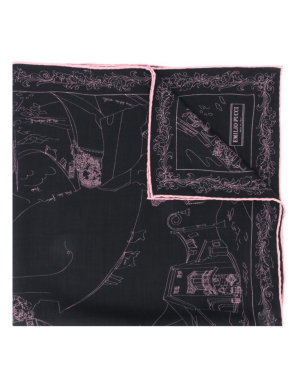

In [89]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(df["first_image"].iloc[0])

plt.imshow(img)
plt.axis("off")
plt.show()

In [90]:
import sklearn

In [91]:
# from sklearn.feature_extraction.text import CountVectorizer

In [92]:
# cv=CountVectorizer(stop_words='english')
from sklearn.feature_extraction.text import TfidfVectorizer
cv=TfidfVectorizer(stop_words='english', max_features=5000)

In [93]:
bow=cv.fit_transform(new_df['tag']).toarray()
print(bow)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [94]:
print(cv.vocabulary_)

{'accessori': np.int64(8), 'littl': np.int64(357), 'make': np.int64(373), 'differ': np.int64(158), 'look': np.int64(362), 'boast': np.int64(64), 'wool': np.int64(744), 'construction': np.int64(118), 'thi': np.int64(674), 'scorci': np.int64(565), 'fiorentini': np.int64(227), 'print': np.int64(517), 'scarf': np.int64(562), 'bring': np.int64(70), 'outfit': np.int64(472), 'emilio': np.int64(194), 'pucci': np.int64(523), 'got': np.int64(255), 'tie': np.int64(677), 'newconditionpucci': np.int64(442), 'cloth': np.int64(104), 'chang': np.int64(94), 'good': np.int64(254), 'switch': np.int64(663), 'loungewear': np.int64(367), 'jil': np.int64(318), 'sander': np.int64(557), 'rib': np.int64(548), 'knit': np.int64(332), 'cotton': np.int64(125), 'skirt': np.int64(598), 'just': np.int64(325), 'comfy': np.int64(112), 'lot': np.int64(366), 'stylish': np.int64(651), 'bet': np.int64(51), 'forgot': np.int64(239), 'feel': np.int64(223), 'like': np.int64(350), 'newconditionjil': np.int64(424), 'oliv': np.int

In [95]:
bow

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [96]:
print(cv.get_feature_names_out())

['100' '19' '1900' '1mid' '3r' '50' 'accent' 'accents' 'accessori'
 'accessories' 'activewear' 'actual' 'add' 'adjustable' 'adorn'
 'aesthetic' 'affin' 'ahead' 'air' 'al' 'alber' 'alexand' 'ambit' 'ami'
 'amp' 'ankl' 'ankles' 'apos' 'appear' 'appliqué' 'approach' 'arrow'
 'astrid' 'asymmetr' 'ateli' 'atop' 'atp' 'attest' 'averag' 'aw2021'
 'away' 'az' 'babi' 'bag' 'bangbang' 'bar' 'bead' 'becom' 'beig' 'belt'
 'belts' 'bet' 'better' 'biker' 'bikini' 'bing' 'black' 'blair' 'blast'
 'blazer' 'blend' 'block' 'blue' 'blueberri' 'boast' 'bold' 'boy'
 'bracelet' 'brand' 'bright' 'bring' 'brown' 'browne' 'brunello' 'buckl'
 'built' 'burch' 'button' 'cademartori' 'camo' 'camouflag' 'capow'
 'capriosca' 'caramel' 'cardigan' 'care' 'cargo' 'cartier' 'casual'
 'celebr' 'centr' 'central' 'centre' 'chain' 'chang' 'charg'
 'checkerboard' 'chest' 'chilli' 'chloé' 'choo' 'classic' 'clearli'
 'closure' 'cloth' 'coat' 'coffee' 'cold' 'collar' 'collection' 'come'
 'comfort' 'comfy' 'complement' 'complet'

In [97]:
from sklearn.metrics.pairwise import cosine_similarity

In [98]:
cosine_similarity(bow)

array([[1.        , 0.03155422, 0.        , ..., 0.0120516 , 0.04892562,
        0.01527417],
       [0.03155422, 1.        , 0.06476991, ..., 0.01686489, 0.07139332,
        0.        ],
       [0.        , 0.06476991, 1.        , ..., 0.00639397, 0.10795642,
        0.        ],
       ...,
       [0.0120516 , 0.01686489, 0.00639397, ..., 1.        , 0.11707325,
        0.16419826],
       [0.04892562, 0.07139332, 0.10795642, ..., 0.11707325, 1.        ,
        0.02045098],
       [0.01527417, 0.        , 0.        , ..., 0.16419826, 0.02045098,
        1.        ]])

In [99]:
similar=cosine_similarity(bow)

In [100]:
list(enumerate(similar[0]))

[(0, np.float64(1.0)),
 (1, np.float64(0.031554224501806095)),
 (2, np.float64(0.0)),
 (3, np.float64(0.023135131104841646)),
 (4, np.float64(0.01707039488490829)),
 (5, np.float64(0.09104964956774955)),
 (6, np.float64(0.05405933572850097)),
 (7, np.float64(0.0)),
 (8, np.float64(0.056358688336905466)),
 (9, np.float64(0.036499578692968694)),
 (10, np.float64(0.01826021053531184)),
 (11, np.float64(0.03234828544005823)),
 (12, np.float64(0.19182449413643382)),
 (13, np.float64(0.0)),
 (14, np.float64(0.06954684524957219)),
 (15, np.float64(0.01456958563822486)),
 (16, np.float64(0.0)),
 (17, np.float64(0.21832285528267717)),
 (18, np.float64(0.0)),
 (19, np.float64(0.0)),
 (20, np.float64(0.0)),
 (21, np.float64(0.030882631001850718)),
 (22, np.float64(0.2342093773688465)),
 (23, np.float64(0.0)),
 (24, np.float64(0.0)),
 (25, np.float64(0.014645049685613242)),
 (26, np.float64(0.0)),
 (27, np.float64(0.0)),
 (28, np.float64(0.290109301962252)),
 (29, np.float64(0.0409258923990799)),


In [101]:
sorted(list(enumerate(similar[0])),reverse=True,key=lambda x:x[1])[1:6]

[(28, np.float64(0.290109301962252)),
 (43, np.float64(0.2760537179192359)),
 (22, np.float64(0.2342093773688465)),
 (17, np.float64(0.21832285528267717)),
 (12, np.float64(0.19182449413643382))]

In [102]:
def recoomand(product):
    matches = new_df[new_df['title'].str.lower().str.contains(product.lower())]
    if matches.empty:
        print("Product not found")
        return

    idx = matches.index[0]
    print(f"Recommendations for: {new_df.loc[idx,'title']}\n")

    dist = similar[idx]
    rlist = sorted(list(enumerate(dist)), reverse=True, key=lambda x: x[1])[1:6]

    for i in rlist:
        row = new_df.iloc[i[0]]
        print(row['title'])

        first_image = row['image_file'].split(" | ")[0]
        if os.path.exists(first_image):
            img = Image.open(first_image)
            plt.imshow(img)
            plt.axis("off")
            plt.title(row['title'])
            plt.show()


Recommendations for: trousers

belt


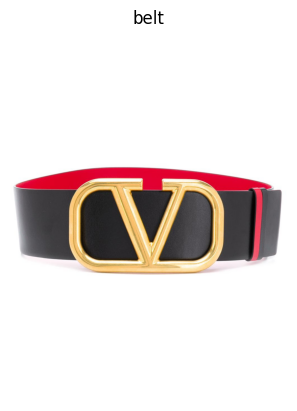

sneakers


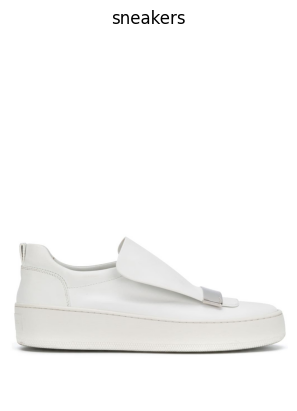

sneakers


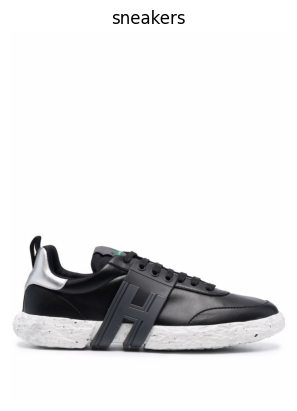

sneakers


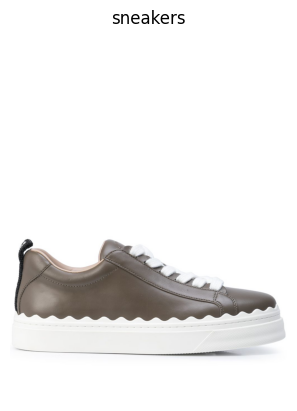

shoes


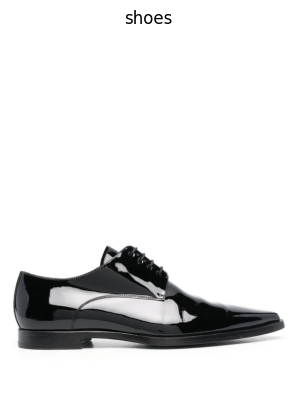

In [106]:
recoomand('trouser')

Recommendations for: shirt

jumper


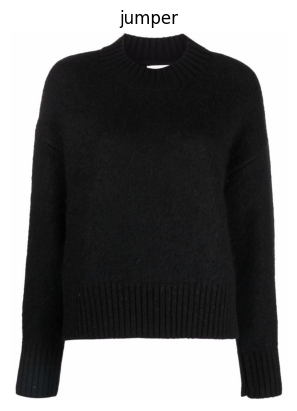

cardigan


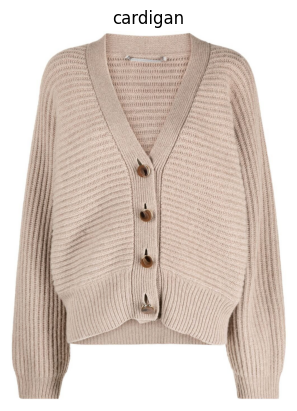

shirt


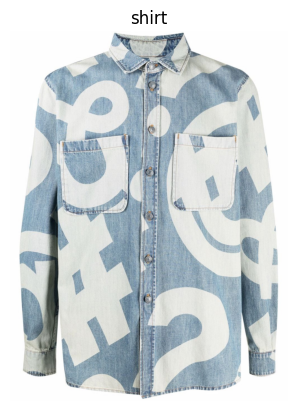

jeans


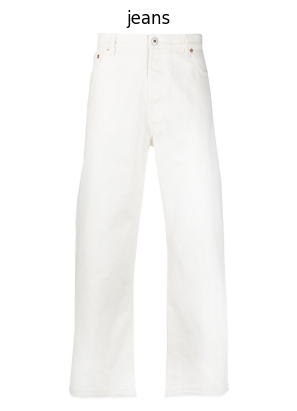

skirt


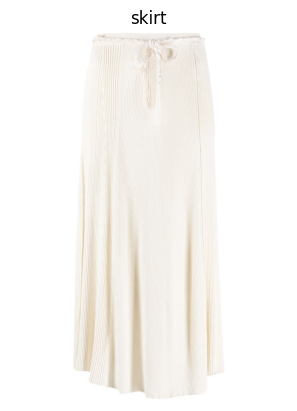

In [104]:
recoomand('shirt')
        

In [105]:
recommend('trousers')


NameError: name 'recommend' is not defined